In [5]:
import pandas as pd
import numpy as np
from scipy.sparse import load_npz
import joblib
import matplotlib.pyplot as plt

In [ ]:
X_sparse = load_npz("tfidfPlusFeatures.npz").tocsr()
column_names = joblib.load("tfidfPlusFeaturesColumns.pkl")

rating_idx = column_names.index('Rating')

y = X_sparse[:, rating_idx].toarray().flatten()

In [4]:
# Remove 'Rating' column from X
mask = np.arange(len(column_names)) != rating_idx
X_sparse_no_rating = X_sparse[:, mask]
features = [col for i, col in enumerate(column_names) if i != rating_idx]

def sparse_pearsonr(x_sparse_col, y):
    """Compute Pearson correlation between a sparse column and dense vector y."""
    x = x_sparse_col.toarray().flatten()
    if np.std(x) == 0 or np.std(y) == 0:
        return 0  # no variation means no correlation
    return np.corrcoef(x, y)[0,1]

correlations = []
for i in range(X_sparse_no_rating.shape[1]):
    corr = sparse_pearsonr(X_sparse_no_rating[:, i], y)
    correlations.append(abs(corr))

# Create series and sort top 10
import pandas as pd
corr_series = pd.Series(correlations, index=features)
top_10 = corr_series.sort_values(ascending=False).head(10)

print("Top 10 features correlated with Rating:")
print(top_10)


Top 10 features correlated with Rating:
not          0.337092
great        0.269334
love         0.200693
waste        0.193784
bad          0.185826
money        0.173966
good         0.160938
excellent    0.149924
return       0.139089
poor         0.131381
dtype: float64


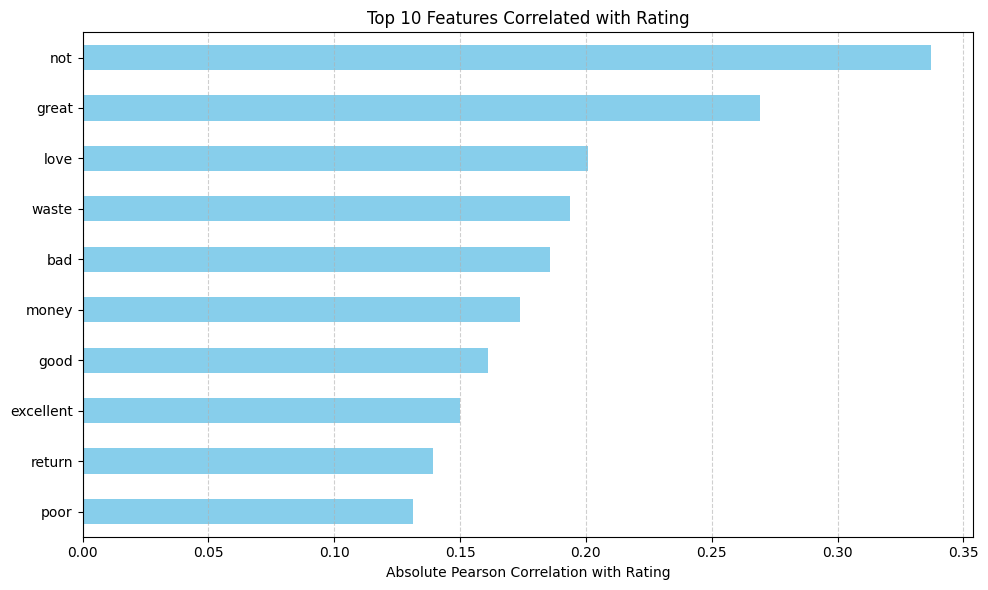

In [6]:
# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
top_10.sort_values().plot(kind='barh', color='skyblue')

plt.xlabel('Absolute Pearson Correlation with Rating')
plt.title('Top 10 Features Correlated with Rating')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


<p>Keeping "not" was a great idea.</p>

<h5>Fares Alfares</h5>